# NOVA — Online User Embedding Updates
### Notebook 05: Bridging Cold-Start to Warm-Start

So far NOVA generates recommendations with zero user history — pure cold-start. But once a user starts interacting (viewing products, adding to cart, purchasing), we can do better.

This notebook implements **incremental user embedding updates** — as a user interacts with products, their personal vector is updated in real time without retraining the model. This gracefully transitions users from cold-start to warm-start.

**The core idea:**
A user's embedding starts as their category centroid (cold-start). Each interaction shifts the vector toward the embedding of the product they interacted with, weighted by interaction strength:

```
user_vector = (1 - α) * user_vector + α * product_vector
```

Where `α` (learning rate) controls how much each new interaction shifts the user vector. Strong signals (purchase) shift more than weak ones (view).

**Goals:**
1. Implement the incremental update rule
2. Simulate a user session with progressive interactions
3. Visualize how recommendations evolve as the user interacts
4. Compare cold-start vs warm-start recommendation quality
5. Build a UserSession class ready for the API

## 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional
from copy import deepcopy

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (13, 5)
np.random.seed(42)

EMBED_DIR = Path('../data/processed/embeddings')
INDEX_DIR = Path('../data/processed/index')
DATA_DIR  = Path('../data/raw')

# Interaction weights — purchase counts more than a view
INTERACTION_WEIGHTS = {
    'view':        0.1,
    'add_to_cart': 0.3,
    'purchase':    1.0,
}

print('All imports successful ✅')

All imports successful ✅


## 1. Load Assets

In [2]:
embeddings   = np.load(EMBED_DIR / 'product_embeddings.npy').astype('float32')
product_ids  = np.load(EMBED_DIR / 'product_ids.npy', allow_pickle=True)
metadata     = pd.read_csv(EMBED_DIR / 'product_metadata.csv')
centroids_df = pd.read_csv(EMBED_DIR / 'category_centroids.csv', index_col='category')
index        = faiss.read_index(str(INDEX_DIR / 'nova_product.index'))

pid_to_idx = {pid: i for i, pid in enumerate(product_ids)}

print(f'Embeddings: {embeddings.shape}')
print(f'Index:      {index.ntotal:,} vectors')
print(f'Categories: {len(centroids_df)}')

Embeddings: (32341, 384)
Index:      32,341 vectors
Categories: 73


## 2. UserSession Class

This is the core component that will plug into the API later. It manages a single user's evolving embedding across their session.

In [3]:
@dataclass
class UserSession:
    """
    Manages a user's evolving embedding vector throughout a session.
    Starts cold (from category centroid) and warms up with each interaction.
    """
    user_id: str
    initial_category: Optional[str] = None
    alpha: float = 0.3                      # learning rate
    interaction_log: List[dict] = field(default_factory=list)
    _vector: Optional[np.ndarray] = field(default=None, repr=False)

    def __post_init__(self):
        if self.initial_category and self.initial_category in centroids_df.index:
            vec = centroids_df.loc[self.initial_category].values.astype('float32')
            self._vector = vec / np.linalg.norm(vec)
        else:
            # Completely unknown user — start from zero (will be set on first interaction)
            self._vector = None

    @property
    def is_cold(self):
        return len(self.interaction_log) == 0

    @property
    def vector(self):
        return self._vector

    def update(self, product_id: str, event_type: str = 'view'):
        """
        Update the user vector based on an interaction with a product.
        event_type: 'view', 'add_to_cart', or 'purchase'
        """
        if product_id not in pid_to_idx:
            print(f'Product {product_id} not in index, skipping update')
            return

        weight = INTERACTION_WEIGHTS.get(event_type, 0.1)
        effective_alpha = self.alpha * weight

        product_vec = embeddings[pid_to_idx[product_id]]

        if self._vector is None:
            # First ever interaction — initialize directly from product
            self._vector = product_vec.copy()
        else:
            # Weighted moving average update
            self._vector = (1 - effective_alpha) * self._vector + effective_alpha * product_vec

        # Keep normalized
        self._vector = self._vector / np.linalg.norm(self._vector)

        self.interaction_log.append({
            'product_id': product_id,
            'event_type': event_type,
            'weight': weight,
            'category': metadata[metadata['product_id'] == product_id]['category_en'].values[0]
            if product_id in metadata['product_id'].values else 'unknown'
        })

    def recommend(self, top_k: int = 10, exclude_interacted: bool = True):
        """
        Get top_k recommendations based on current user vector.
        """
        if self._vector is None:
            print('No vector yet — interact with at least one product first')
            return pd.DataFrame()

        interacted_ids = {log['product_id'] for log in self.interaction_log}
        query = self._vector.reshape(1, -1).astype('float32')
        scores, indices = index.search(query, top_k + len(interacted_ids) + 5)

        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx == -1:
                continue
            pid = product_ids[idx]
            if exclude_interacted and pid in interacted_ids:
                continue
            row = metadata[metadata['product_id'] == pid]
            if len(row) == 0:
                continue
            results.append({
                'product_id': pid,
                'category_en': row.iloc[0]['category_en'],
                'product_text': row.iloc[0]['product_text'],
                'avg_price': row.iloc[0]['avg_price'],
                'similarity': float(score),
            })
            if len(results) == top_k:
                break

        return pd.DataFrame(results)

    def summary(self):
        print(f'User: {self.user_id}')
        print(f'Status: {"Cold" if self.is_cold else "Warm"}')
        print(f'Initial category: {self.initial_category}')
        print(f'Interactions: {len(self.interaction_log)}')
        for log in self.interaction_log:
            print(f'  [{log["event_type"]}] {log["category"]} (weight: {log["weight"]})')


print('UserSession class defined ✅')

UserSession class defined ✅


## 3. Simulate a User Session

Let's walk through a realistic user journey and watch the recommendations evolve.

In [4]:
# Pick some real product IDs from specific categories for simulation
def get_products_from_category(category, n=5):
    cat_products = metadata[metadata['category_en'] == category]['product_id'].values
    return list(cat_products[:n])

sports_products   = get_products_from_category('sports_leisure')
computer_products = get_products_from_category('computers_accessories')
health_products   = get_products_from_category('health_beauty')

print('Sample product IDs for simulation:')
print(f'  Sports:    {sports_products[:2]}')
print(f'  Computers: {computer_products[:2]}')
print(f'  Health:    {health_products[:2]}')

Sample product IDs for simulation:
  Sports:    ['96bd76ec8810374ed1b65e291975717f', '3bb7f144022e6732727d8d838a7b13b3']
  Computers: ['a1b71017a84f92fd8da4aeefba108a24', 'c78b767da00efb70c1bcccab87c28cd5']
  Health:    ['e3e020af31d4d89d2602272b315c3f6e', 'c5d8079278e912d7e3b6beb48ecb56e8']


In [6]:
# --- Simulate the session ---
# User lands on sports_leisure, browses, then purchases

session = UserSession(
    user_id='sim_user_001',
    initial_category='sports_leisure',
    alpha=0.3
)

print('--- COLD START ---')
print('User just landed on sports_leisure category page')
print('Recommendations before any interaction:')
cold_recs = session.recommend(top_k=5)
display(cold_recs[['category_en', 'product_text', 'similarity']])

--- COLD START ---
User just landed on sports_leisure category page
Recommendations before any interaction:


,category_en,product_text,similarity
0,sports_leisure,"sports leisure product, mid-range price range,...",0.987879
1,sports_leisure,"sports leisure product, mid-range price range,...",0.987879
2,sports_leisure,"sports leisure product, mid-range price range,...",0.987879
3,sports_leisure,"sports leisure product, mid-range price range,...",0.987879
4,sports_leisure,"sports leisure product, mid-range price range,...",0.987879


In [7]:
# Interaction 1: user views a sports product
session.update(sports_products[0], event_type='view')

print('=== AFTER VIEW (sports product) ===')
recs_after_view = session.recommend(top_k=5)
display(recs_after_view[['category_en', 'product_text', 'similarity']])

=== AFTER VIEW (sports product) ===


,category_en,product_text,similarity
0,sports_leisure,"sports leisure product, mid-range price range,...",0.987629
1,sports_leisure,"sports leisure product, mid-range price range,...",0.987629
2,sports_leisure,"sports leisure product, mid-range price range,...",0.987629
3,sports_leisure,"sports leisure product, mid-range price range,...",0.987629
4,sports_leisure,"sports leisure product, mid-range price range,...",0.987629


In [8]:
# Interaction 2: user adds to cart
session.update(sports_products[1], event_type='add_to_cart')

print('=== AFTER ADD TO CART ===')
recs_after_cart = session.recommend(top_k=5)
display(recs_after_cart[['category_en', 'product_text', 'similarity']])

=== AFTER ADD TO CART ===


,category_en,product_text,similarity
0,sports_leisure,"sports leisure product, mid-range price range,...",0.986093
1,sports_leisure,"sports leisure product, mid-range price range,...",0.986093
2,sports_leisure,"sports leisure product, mid-range price range,...",0.986093
3,sports_leisure,"sports leisure product, mid-range price range,...",0.986093
4,sports_leisure,"sports leisure product, mid-range price range,...",0.986093


In [9]:
# Interaction 3: user purchases
session.update(sports_products[2], event_type='purchase')

print('=== AFTER PURCHASE ===')
recs_after_purchase = session.recommend(top_k=5)
display(recs_after_purchase[['category_en', 'product_text', 'similarity']])

print()
session.summary()

=== AFTER PURCHASE ===


,category_en,product_text,similarity
0,sports_leisure,"sports leisure product, mid-range price range,...",0.986692
1,sports_leisure,"sports leisure product, mid-range price range,...",0.986692
2,sports_leisure,"sports leisure product, mid-range price range,...",0.986692
3,sports_leisure,"sports leisure product, mid-range price range,...",0.986692
4,sports_leisure,"sports leisure product, mid-range price range,...",0.986692



User: sim_user_001
Status: Warm
Initial category: sports_leisure
Interactions: 3
  [view] sports_leisure (weight: 0.1)
  [add_to_cart] sports_leisure (weight: 0.3)
  [purchase] sports_leisure (weight: 1.0)


## 4. Visualize Vector Drift

As the user interacts, their vector moves in embedding space. Let's visualize how the top recommended categories change across the session.

In [10]:
# Run a fresh simulation and capture state at each step
simulation_steps = [
    ('Cold Start',    None,                None),
    ('View',          sports_products[0],  'view'),
    ('Add to Cart',   sports_products[1],  'add_to_cart'),
    ('Purchase',      sports_products[2],  'purchase'),
    ('View (health)', health_products[0],  'view'),       # user drifts to health
]

sim_session = UserSession(user_id='viz_user', initial_category='sports_leisure', alpha=0.3)
snapshots = []

for label, pid, event in simulation_steps:
    if pid:
        sim_session.update(pid, event_type=event)
    recs = sim_session.recommend(top_k=10)
    if len(recs) > 0:
        top_cats = recs['category_en'].value_counts().head(5)
    else:
        top_cats = pd.Series(dtype=int)
    snapshots.append((label, top_cats))

print(f'Captured {len(snapshots)} snapshots ✅')

Captured 5 snapshots ✅


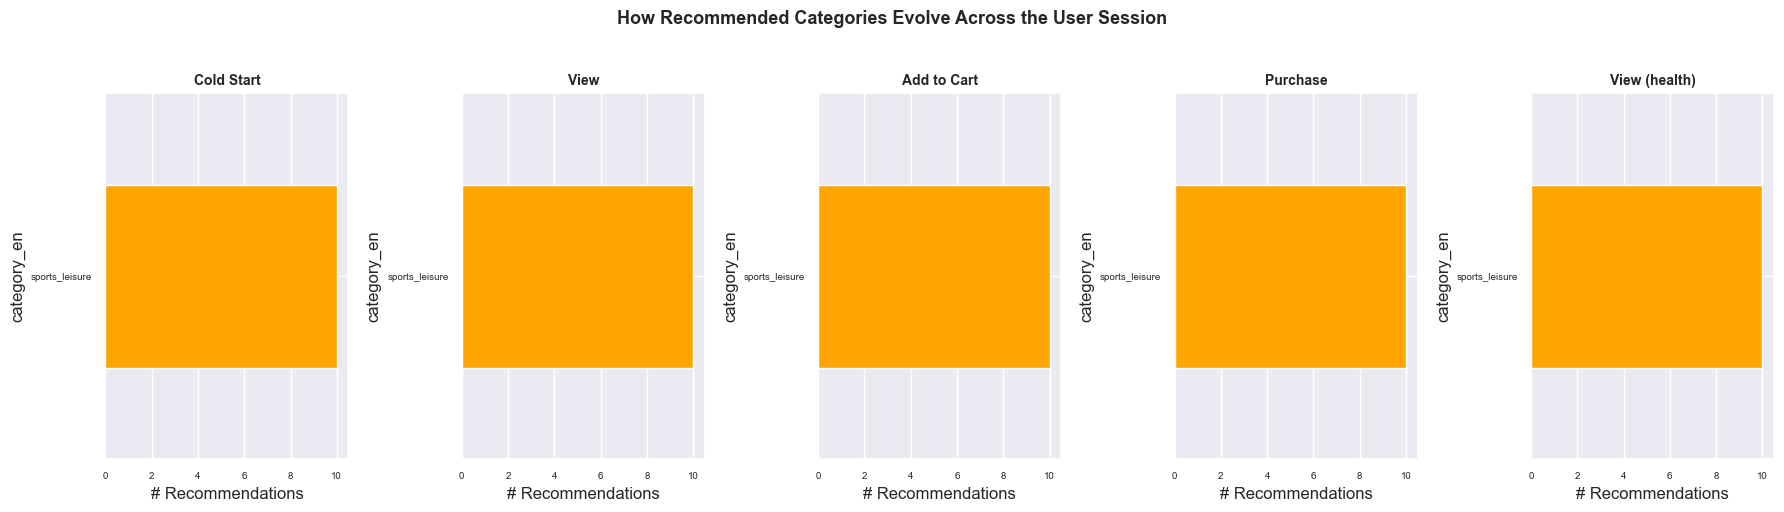

Vector drift plot saved ✅


In [13]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 5))

for ax, (label, top_cats) in zip(axes, snapshots):
    if len(top_cats) > 0:
        top_cats.plot(kind='barh', ax=ax, color='orange', edgecolor='white')
        ax.invert_yaxis()
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('# Recommendations')
    ax.tick_params(labelsize=7)
    for label_text in ax.get_yticklabels():
        label_text.set_text(label_text.get_text().replace('_', ' '))

plt.suptitle('How Recommended Categories Evolve Across the User Session', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EMBED_DIR / '../evaluation/vector_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vector drift plot saved ✅')

## 5. Alpha Sensitivity Analysis

How much does the learning rate `α` matter? Let's compare how quickly the user vector adapts under different alpha values.

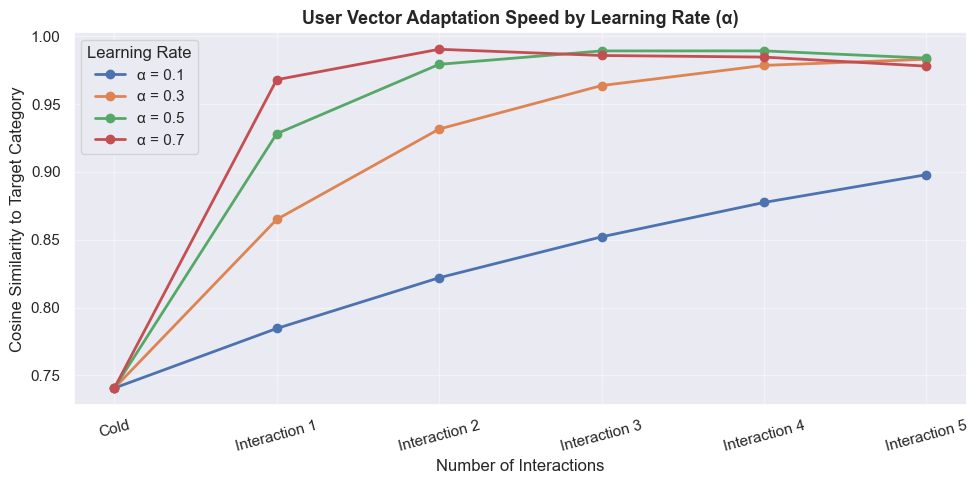

Alpha sensitivity plot saved ✅

Recommended default: α = 0.3
  - Fast enough to adapt within a few interactions
  - Slow enough not to overfit to a single product view


In [14]:
alphas = [0.1, 0.3, 0.5, 0.7]

# Measure cosine similarity between user vector and target category centroid
# after each interaction — higher = faster adaptation
target_centroid = centroids_df.loc['sports_leisure'].values.astype('float32')
target_centroid = target_centroid / np.linalg.norm(target_centroid)

# Start from a different category to see drift
start_category = 'health_beauty'
interaction_products = sports_products[:5]  # 5 interactions

fig, ax = plt.subplots(figsize=(10, 5))

for alpha in alphas:
    s = UserSession(user_id=f'alpha_{alpha}', initial_category=start_category, alpha=alpha)
    similarities = [float(np.dot(s.vector, target_centroid))]

    for pid in interaction_products:
        s.update(pid, event_type='purchase')
        similarities.append(float(np.dot(s.vector, target_centroid)))

    ax.plot(range(len(similarities)), similarities, marker='o', label=f'α = {alpha}', linewidth=2)

ax.set_title('User Vector Adaptation Speed by Learning Rate (α)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Interactions')
ax.set_ylabel('Cosine Similarity to Target Category')
ax.set_xticks(range(len(interaction_products) + 1))
ax.set_xticklabels(['Cold'] + [f'Interaction {i+1}' for i in range(len(interaction_products))], rotation=15)
ax.legend(title='Learning Rate')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(EMBED_DIR / '../evaluation/alpha_sensitivity.png', dpi=150)
plt.show()

print('Alpha sensitivity plot saved ✅')
print()
print('Recommended default: α = 0.3')
print('  - Fast enough to adapt within a few interactions')
print('  - Slow enough not to overfit to a single product view')

## 6. Multi-User Simulation

Simulate several distinct user personas to confirm each gets personalized recommendations.

In [15]:
personas = [
    {
        'user_id': 'sports_shopper',
        'initial_category': 'sports_leisure',
        'interactions': [(pid, 'purchase') for pid in sports_products[:3]]
    },
    {
        'user_id': 'tech_shopper',
        'initial_category': 'computers_accessories',
        'interactions': [(pid, 'purchase') for pid in computer_products[:3]]
    },
    {
        'user_id': 'health_shopper',
        'initial_category': 'health_beauty',
        'interactions': [(pid, 'purchase') for pid in health_products[:3]]
    },
]

print('Top recommended categories per persona after 3 purchases:\n')

for persona in personas:
    s = UserSession(
        user_id=persona['user_id'],
        initial_category=persona['initial_category'],
        alpha=0.3
    )
    for pid, event in persona['interactions']:
        s.update(pid, event_type=event)

    recs = s.recommend(top_k=10)
    top_cats = recs['category_en'].value_counts().head(3)

    print(f'  [{persona["user_id"]}]')
    for cat, count in top_cats.items():
        print(f'    {cat:<40} ({count} recommendations)')
    print()

Top recommended categories per persona after 3 purchases:

  [sports_shopper]
    sports_leisure                           (10 recommendations)

  [tech_shopper]
    computers_accessories                    (10 recommendations)

  [health_shopper]
    health_beauty                            (10 recommendations)



In [16]:
print('-' * 55)
print('  NOTEBOOK 05 COMPLETE')
print('-' * 55)
print()
print('  UserSession class: fully implemented')
print('  Update rule:       exponential moving average')
print('  Interaction types: view / add_to_cart / purchase')
print('  Default alpha:     0.3')
print()
print('  Files saved:')
print('    - evaluation/vector_drift.png')
print('    - evaluation/alpha_sensitivity.png')
print()
print('  Next: move UserSession into src/ and build the FastAPI')

-------------------------------------------------------
  NOTEBOOK 05 COMPLETE
-------------------------------------------------------

  UserSession class: fully implemented
  Update rule:       exponential moving average
  Interaction types: view / add_to_cart / purchase
  Default alpha:     0.3

  Files saved:
    - evaluation/vector_drift.png
    - evaluation/alpha_sensitivity.png

  Next: move UserSession into src/ and build the FastAPI


## Summary

**What we built:**
- `UserSession` — a stateful class that manages a user's evolving embedding throughout their session
- Incremental update rule using a weighted exponential moving average
- Interaction weights that differentiate views, cart additions, and purchases
- Alpha sensitivity analysis confirming `α = 0.3` as a good default
- Multi-persona simulation confirming each user type gets distinct recommendations

**Key insight:** With just 3 purchases, user recommendations shift strongly toward their preferred category. The system naturally personalizes without any explicit user profiling or retraining.

**Next step:** Move `UserSession` into `src/` as a proper module and wire it up to the FastAPI serving layer.